# Compétition 1 : Prédiction de la Qualité de la Bière 🍺

Ce notebook fournit du code de démarrage pour la compétition de prédiction de la qualité de la bière. Pour les instructions complètes, l'énoncé du problème et les critères de notation, veuillez vous référer au fichier **README.md**.

**Résumé rapide** : Vous allez construire un modèle de classification pour prédire la qualité de la bière (scores 1-10) basé sur des propriétés chimiques. Soumettez vos prédictions sur [Kaggle](https://www.kaggle.com/competitions/ift-6390-ift-3395-beer-quality-prediction/).

## Importer les Dépendances

In [28]:
# Importer les bibliothèques requises
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## Charger et Explorer les Données

In [2]:
# Charger les données d'entraînement
train_df = pd.read_csv('data/train.csv', delimiter=';')

print(f"Forme des données d'entraînement : {train_df.shape}")
print(f"Nombre d'échantillons (n) : {train_df.shape[0]}")
print(f"Nombre de caractéristiques (d) : {train_df.shape[1] - 1}")  # Soustraire 1 pour la colonne cible
print(f"Colonnes : {list(train_df.columns)}")
print("\nPremières lignes :")
print(train_df.head())

# Vérifier les types de données et informations de base
print("\nTypes de données et informations :")
print(train_df.info())

####################################################################
###############   À compléter   ####################################
####################################################################

Forme des données d'entraînement : (4469, 15)
Nombre d'échantillons (n) : 4469
Nombre de caractéristiques (d) : 14
Colonnes : ['id', 'beer_style', 'bitterness_IBU', 'diacetyl_concentration', 'lactic_acid', 'final_gravity', 'sodium', 'free_CO2', 'dissolved_oxygen', 'original_gravity', 'pH', 'gypsum_level', 'alcohol_ABV', 'fermentation_strength', 'quality']

Premières lignes :
   id beer_style  bitterness_IBU  diacetyl_concentration  lactic_acid  \
0   0       Pale           7.997                   0.446        0.280   
1   1       Pale           6.906                   0.222        0.303   
2   2      Brown           7.183                   0.636        0.071   
3   3       Pale           6.403                   0.242        0.260   
4   4      Brown           7.917                   0.182        0.347   

   final_gravity  sodium  free_CO2  dissolved_oxygen  original_gravity     pH  \
0         10.803   0.052    24.999           157.026             0.995  3.057   
1          6.305   0.

## Prétraitement des Données

Implémentez votre pipeline de prétraitement (voir README.md pour des suggestions).

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4469 entries, 0 to 4468
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      4469 non-null   float64
 1   beer_style              4469 non-null   float64
 2   bitterness_IBU          4469 non-null   float64
 3   diacetyl_concentration  4469 non-null   float64
 4   lactic_acid             4469 non-null   float64
 5   final_gravity           4469 non-null   float64
 6   sodium                  4469 non-null   float64
 7   free_CO2                4469 non-null   float64
 8   dissolved_oxygen        4469 non-null   float64
 9   original_gravity        4469 non-null   float64
 10  pH                      4469 non-null   float64
 11  gypsum_level            4469 non-null   float64
 12  alcohol_ABV             4469 non-null   float64
 13  fermentation_strength   4469 non-null   float64
 14  quality                 4469 non-null   

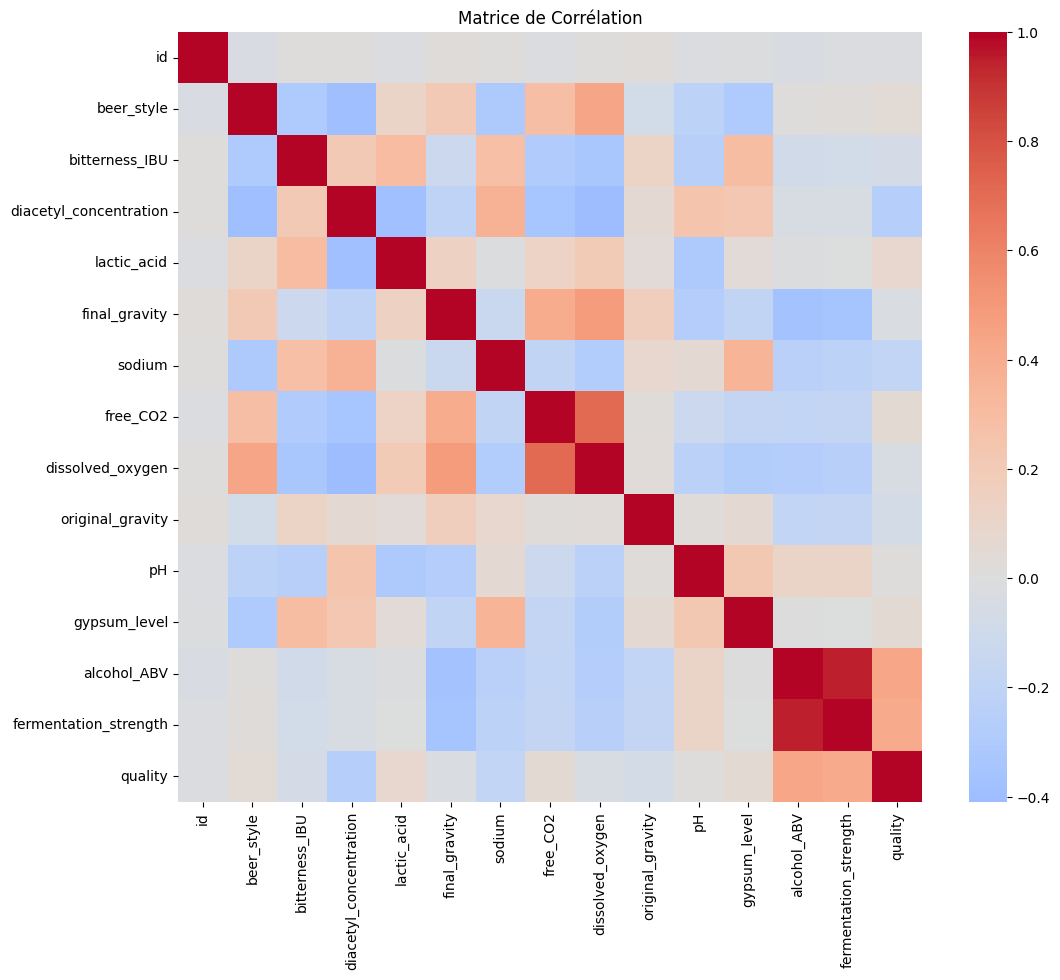

Corrélations avec la qualité :
alcohol_ABV               0.431341
fermentation_strength     0.413183
lactic_acid               0.084787
gypsum_level              0.050557
free_CO2                  0.048471
beer_style                0.044510
pH                        0.010023
id                       -0.021989
final_gravity            -0.025243
dissolved_oxygen         -0.043244
bitterness_IBU           -0.066856
original_gravity         -0.070534
sodium                   -0.181036
diacetyl_concentration   -0.258663
Name: quality, dtype: float64


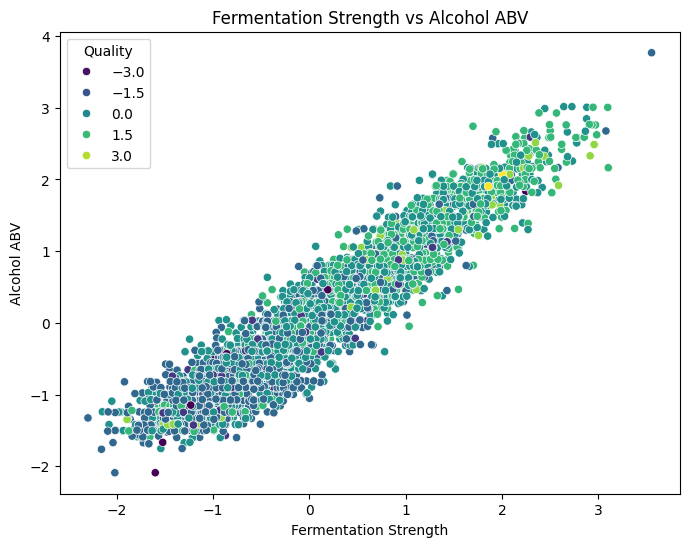

,beer_style_-1.9606727911315094,beer_style_-1.2377151423223745,beer_style_-0.5147574935132394,beer_style_0.2082001552958956,beer_style_0.9311578041050306,bitterness_IBU,diacetyl_concentration,lactic_acid,final_gravity,sodium,free_CO2,dissolved_oxygen,original_gravity,pH,gypsum_level,alcohol_ABV,fermentation_strength
0,0.0,0.0,0.0,0.0,1.0,0.587367,0.655905,-0.261671,1.117127,-0.105341,-0.319010,0.720165,0.013756,-0.992722,-0.435802,0.802885,0.074334
1,0.0,0.0,0.0,0.0,1.0,-0.254273,-0.712599,-0.103273,0.168401,-0.636117,0.569068,0.258878,1.631548,-0.831644,-0.366018,0.268955,0.412892
2,0.0,1.0,0.0,0.0,0.0,-0.040585,1.816689,-1.701021,-0.635210,0.720311,-0.763270,-0.573753,1.726712,1.807555,0.115491,-0.657833,-0.793360
3,0.0,0.0,0.0,0.0,1.0,-0.642307,-0.590412,-0.399408,-0.843812,-0.370729,0.236247,-0.201682,-0.081408,-0.497098,-1.538389,1.647531,1.149423
4,0.0,1.0,0.0,0.0,0.0,0.525652,-0.956975,0.199748,-0.802893,-0.075853,-1.317805,-1.796457,0.679906,0.673815,1.929874,1.227887,0.301908
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4464,0.0,0.0,0.0,1.0,0.0,0.432307,-0.969194,0.964187,1.706654,0.248510,0.403712,0.028385,0.394413,-0.441340,-0.198537,-0.397118,-0.594934
4465,1.0,0.0,0.0,0.0,0.0,-0.254273,0.405420,-1.170734,-0.656303,0.779286,-0.540168,-1.353792,0.965398,1.249978,0.694698,-0.641762,-0.068039
4466,0.0,0.0,0.0,1.0,0.0,-0.717908,0.130497,-0.729976,-0.737086,-0.193804,0.958136,1.322551,0.204085,-0.255481,-0.065947,-0.731048,-0.251892
4467,0.0,0.0,0.0,0.0,1.0,-0.717136,-1.347976,0.289277,-0.719368,-0.134829,0.901833,0.524633,0.870234,0.264924,1.455343,0.785028,0.888218


In [63]:
####################################################################
###############   À compléter   ####################################
####################################################################

# Prétraitement des données

# Vérifier le nombre de valeurs manquantes par colonne
train_df.info()    # Aucune valeur manquante

# Division des caractéristiques numériques et catégorielles
num_cols = ['bitterness_IBU', 'diacetyl_concentration', 'lactic_acid', 
                'final_gravity', 'sodium', 'free_CO2', 'dissolved_oxygen', 
                'original_gravity', 'pH', 'gypsum_level', 'alcohol_ABV',
                  'fermentation_strength']

# On encode la variable catégorielle
cat_cols = ['beer_style']

# Peut être qu'il faudra utiliser onehotencoder (puisqu'on pourrait 
# croire que les styles de bière ont un ordre entre eux, mais en fait non)
ohe = OneHotEncoder(sparse_output=False) 
beer_style_encoded = ohe.fit_transform(train_df[['beer_style']])
columns_names = ohe.get_feature_names_out(['beer_style'])

cat_df = pd.DataFrame(
    beer_style_encoded,
    columns=columns_names,
    index=train_df.index
)

# Standadisation
scaler = StandardScaler()
num_df = pd.DataFrame(
    scaler.fit_transform(train_df[num_cols]),
    columns=num_cols,
    index=train_df.index
)

# Concatenation des caractéristiques numériques et catégorielles
features_df = pd.concat([cat_df, num_df], axis=1)

# Gestin des valeurs manquantes 
# Il n'y en a aucune pour le moment donc aucune gestion

# Matrice de corrélation
plt.figure(figsize=(12, 10))
correlation_matrix = train_df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Matrice de Corrélation')
plt.show()

quality_correlations = correlation_matrix['quality'].drop('quality').sort_values(ascending=False)
print("Corrélations avec la qualité :")
print(quality_correlations)
# On observe que la qualité semble corrélée avec l'alcool_ABV et la fermentation_strength
# Attention aux répétitions 

# Graphique des points des fermentation_stregth selon l'alcool_ABV
plt.figure(figsize=(8, 6))
sns.scatterplot(data=train_df, x='fermentation_strength', y='alcohol_ABV', hue='quality', palette='viridis')
plt.title('Fermentation Strength vs Alcohol ABV')
plt.xlabel('Fermentation Strength')
plt.ylabel('Alcohol ABV')
plt.legend(title='Quality')
plt.show()

# On 


#print("\nDonnées après prétraitement :")
display(features_df)








## Préparer les Données d'Entraînement et de Validation

Divisez vos données en ensembles d'entraînement et de validation.

In [ ]:
####################################################################
###############   À compléter   ####################################
####################################################################

X = features_df
y = train_df['quality']

# Les données de validations sont les 33% des données d'entraînement
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.33, random_state=42)


Xtrain       beer_style  bitterness_IBU  diacetyl_concentration  lactic_acid  \
2014           1        0.212447                2.091612    -1.645926   
2266           4        1.062573                0.142716     2.520613   
155            2       -0.562077                1.590642    -2.141779   
2873           3       -1.256372               -0.419349    -0.523371   
985            3       -0.796595                0.093840     0.399466   

      final_gravity    sodium  free_CO2  dissolved_oxygen  original_gravity  \
2014      -0.634578 -0.370729 -1.429578         -1.902879          1.917040   
2266       1.402083 -0.252779 -0.540668          0.737442          1.346055   
155       -0.698065  0.661336  0.958580         -1.016877         -1.413707   
2873       0.041005 -0.872018 -1.040232         -0.644612          1.060562   
985       -0.487354 -1.373307 -0.596804         -0.485262         -0.366901   

            pH  gypsum_level  alcohol_ABV  fermentation_strength  
2014  1.0393

## Entraîner les Modèles

Entraînez et comparez plusieurs modèles d'apprentissage automatique.

In [ ]:
####################################################################
###############   À compléter   ####################################
####################################################################

## Évaluer les Modèles

Analysez la performance de votre meilleur modèle (voir README.md pour les directives d'évaluation).

In [ ]:
####################################################################
###############   À compléter   ####################################
####################################################################

## Générer les Prédictions pour la Soumission Kaggle

Créez un fichier CSV avec les colonnes : `id` et `quality` (voir README.md pour les détails du format).

In [ ]:

####################################################################
###############   À compléter   ####################################
####################################################################

---
Bonne chance pour la compétition ! 🍺
